# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [1]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [2]:
filename="../Lab.7/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

In [3]:
import sys
!{sys.executable} -m pip install scikit-learn

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [4]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [5]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [6]:
Fisher.fit(X_Train,y_Train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


We can plot the output, comparing signal and background:

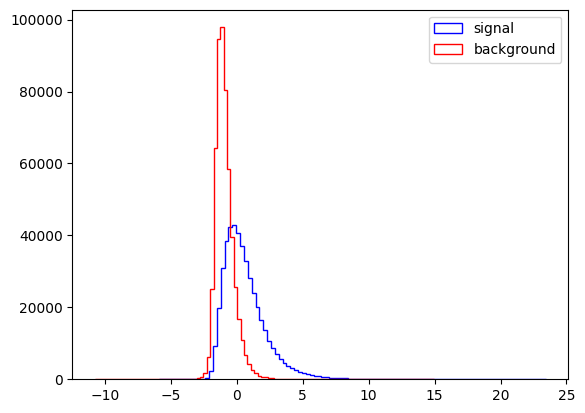

In [7]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

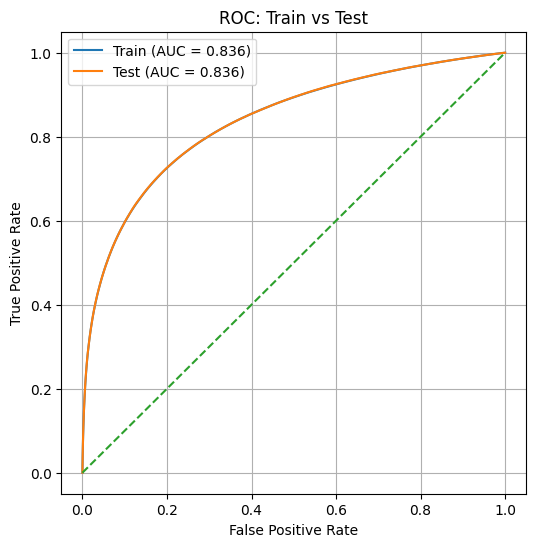

In [8]:
from sklearn.metrics import roc_curve, auc

train_scores = Fisher.decision_function(X_Train)
fpr_train, tpr_train, _ = roc_curve(y_Train, train_scores)
auc_train = auc(fpr_train, tpr_train)

test_scores = Fisher.decision_function(X_Test)
fpr_test, tpr_test, _ = roc_curve(y_Test, test_scores)
auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(6,6))
plt.plot(fpr_train, tpr_train, label=f"Train (AUC = {auc_train:.3f})")
plt.plot(fpr_test, tpr_test, label=f"Test (AUC = {auc_test:.3f})")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC: Train vs Test")
plt.legend()
plt.grid()
plt.show()

In [9]:
#The ROC curves for the training and test datasets are very similar, indicating that the model does not suffer from significant overfitting. The comparable AUC values suggest that the classifier generalizes well to unseen data. If a noticeable gap were present, it would indicate overfitting (training performing better than testing).

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

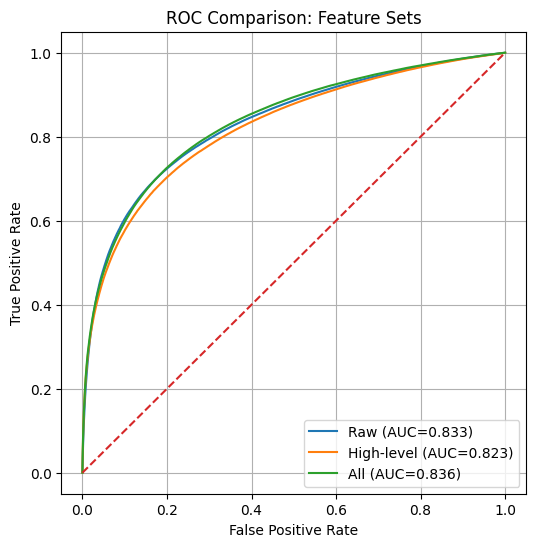

In [10]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_curve, auc

raw_features = VarNames[1:9]
high_features = VarNames[9:]
all_features = VarNames[1:]

def get_roc(X_train, X_test, y_train, y_test):
    model = LinearDiscriminantAnalysis()
    model.fit(X_train, y_train)
    scores = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, scores)
    return fpr, tpr, auc(fpr, tpr)

fpr_raw, tpr_raw, auc_raw = get_roc(
    X_Train[raw_features], X_Test[raw_features], y_Train, y_Test)

fpr_high, tpr_high, auc_high = get_roc(
    X_Train[high_features], X_Test[high_features], y_Train, y_Test)

fpr_all, tpr_all, auc_all = get_roc(
    X_Train[all_features], X_Test[all_features], y_Train, y_Test)

plt.figure(figsize=(6,6))
plt.plot(fpr_raw, tpr_raw, label=f"Raw (AUC={auc_raw:.3f})")
plt.plot(fpr_high, tpr_high, label=f"High-level (AUC={auc_high:.3f})")
plt.plot(fpr_all, tpr_all, label=f"All (AUC={auc_all:.3f})")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison: Feature Sets")
plt.legend()
plt.grid()
plt.show()

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 6.

In [ ]:
#logistic regression, naive bayes, small decision tree

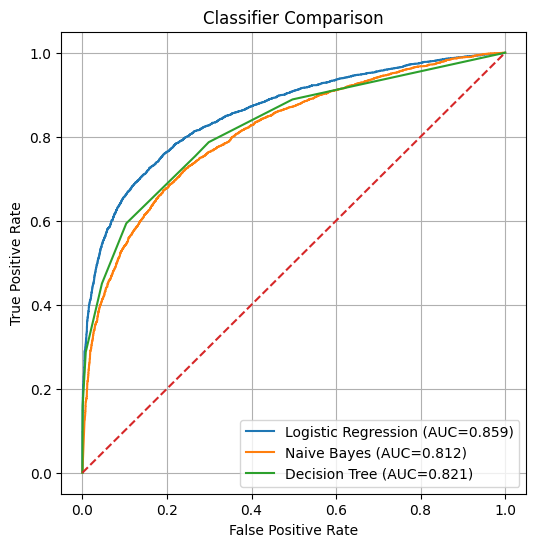

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

sample_size = 10000

idx_train = np.random.choice(len(X_Train), sample_size, replace=False)
idx_test = np.random.choice(len(X_Test), sample_size, replace=False)

Xtr = X_Train.iloc[idx_train][VarNames[1:]]
ytr = y_Train.iloc[idx_train]

Xte = X_Test.iloc[idx_test][VarNames[1:]]
yte = y_Test.iloc[idx_test]

def evaluate_model(model):
    model.fit(Xtr, ytr)
    
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(Xte)[:,1]
    else:
        scores = model.decision_function(Xte)
    
    fpr, tpr, _ = roc_curve(yte, scores)
    return fpr, tpr, auc(fpr, tpr)

models = [
    (LogisticRegression(max_iter=300), "Logistic Regression"),
    (GaussianNB(), "Naive Bayes"),
    (DecisionTreeClassifier(max_depth=3), "Decision Tree")
]

plt.figure(figsize=(6,6))

for model, name in models:
    fpr, tpr, auc_val = evaluate_model(model)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Classifier Comparison")
plt.legend()
plt.grid()

plt.show()

In [13]:
import numpy as np

df_small = df.sample(20000, random_state=42)

X = df_small[VarNames[1:]]
y = df_small["signal"]

from sklearn.model_selection import train_test_split
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=200)
model.fit(Xtr, ytr)

scores = model.predict_proba(Xte)[:,1]

Ns = 1000
Nb = 10000

thresholds = np.linspace(min(scores), max(scores), 100)
best_sigma = 0
best_t = 0

for t in thresholds:
    eps_s = np.sum((scores >= t) & (yte == 1)) / np.sum(yte == 1)
    eps_b = np.sum((scores >= t) & (yte == 0)) / np.sum(yte == 0)

    Ns_p = eps_s * Ns
    Nb_p = eps_b * Nb

    if Ns_p + Nb_p > 0:
        sigma = Ns_p / np.sqrt(Ns_p + Nb_p)
        if sigma > best_sigma:
            best_sigma = sigma
            best_t = t

print("Best significance:", round(best_sigma,3))
print("Best threshold:", round(best_t,3))

Best significance: 16.959
Best threshold: 0.727


### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

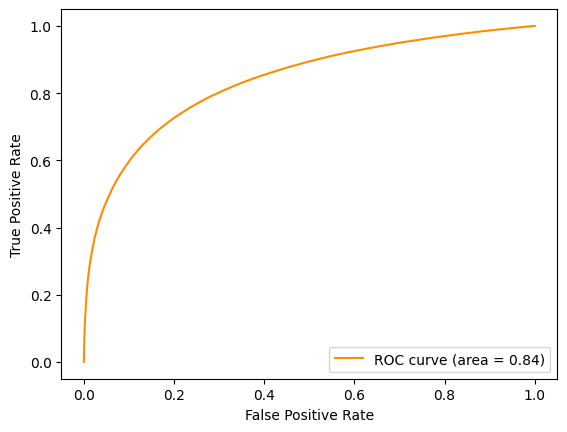

In [14]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [15]:
from sklearn.metrics import (
    roc_curve, auc, precision_score, recall_score,
    f1_score, accuracy_score
)
from tabulate import tabulate
import numpy as np

df_small = df.sample(20000, random_state=42)

X = df_small[VarNames[1:]]
y = df_small["signal"]

from sklearn.model_selection import train_test_split
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=200)
model.fit(Xtr, ytr)

scores = model.predict_proba(Xte)[:,1]

fpr, tpr, thresholds = roc_curve(yte, scores)
roc_auc = auc(fpr, tpr)

Ns, Nb = 1000, 10000

best_sigma = 0
best_t = 0

for t in thresholds:
    eps_s = np.sum((scores >= t) & (yte == 1)) / np.sum(yte == 1)
    eps_b = np.sum((scores >= t) & (yte == 0)) / np.sum(yte == 0)

    Ns_p = eps_s * Ns
    Nb_p = eps_b * Nb

    if Ns_p + Nb_p > 0:
        sigma = Ns_p / np.sqrt(Ns_p + Nb_p)
        if sigma > best_sigma:
            best_sigma = sigma
            best_t = t

y_pred = (scores >= best_t).astype(int)

precision = precision_score(yte, y_pred)
recall = recall_score(yte, y_pred)
f1 = f1_score(yte, y_pred)
accuracy = accuracy_score(yte, y_pred)

tp = np.sum((y_pred == 1) & (yte == 1))
fp = np.sum((y_pred == 1) & (yte == 0))
fn = np.sum((y_pred == 0) & (yte == 1))
tn = np.sum((y_pred == 0) & (yte == 0))

tpr_val = tp / (tp + fn)
fpr_val = fp / (fp + tn)

table = [
    ["TPR", round(tpr_val,3)],
    ["FPR", round(fpr_val,3)],
    ["AUC", round(roc_auc,3)],
    ["Precision", round(precision,3)],
    ["Recall", round(recall,3)],
    ["F1 Score", round(f1,3)],
    ["Accuracy", round(accuracy,3)],
    ["Max Significance", round(best_sigma,3)]
]

print(tabulate(table, headers=["Metric", "Value"], tablefmt="grid"))

+------------------+---------+
| Metric           |   Value |
+==================+=========+
| TPR              |   0.455 |
+------------------+---------+
| FPR              |   0.026 |
+------------------+---------+
| AUC              |   0.86  |
+------------------+---------+
| Precision        |   0.937 |
+------------------+---------+
| Recall           |   0.455 |
+------------------+---------+
| F1 Score         |   0.613 |
+------------------+---------+
| Accuracy         |   0.735 |
+------------------+---------+
| Max Significance |  16.986 |
+------------------+---------+
